Dataset contains 3134 counties and 44 columns.

--- Missing Values in Key Columns ---
Cost Per Meal                0
GROCPTH20                  908
SNAP_Gap_Ratio               1
Median_Household_Income      1
mean_commute_time            0
poverty_rate                 0
population_density           0
min_wage_2023                0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Cost Per Meal,3134.0,3.578918,0.348473,2.600000,3.360000,3.520000,3.720000,6.090000
GROCPTH20,2226.0,0.225797,0.178810,0.037616,0.134698,0.179047,0.256123,2.335357
SNAP_Gap_Ratio,3133.0,0.606101,0.136271,0.167470,0.512847,0.603245,0.691667,1.000000
Median_Household_Income,3133.0,65478.503351,16491.771946,28579.000000,54599.000000,62758.000000,73004.000000,173655.000000
mean_commute_time,3134.0,24.363114,5.723229,4.900000,20.600000,24.100000,28.100000,49.600000
poverty_rate,3134.0,14.242916,5.948328,1.400000,10.000000,13.200000,17.375000,57.600000
population_density,3134.0,275.485755,1804.892137,0.035684,16.019899,44.616255,119.275320,71916.188543
min_wage_2023,3134.0,9.437776,2.639347,5.150000,7.250000,7.250000,12.000000,17.000000


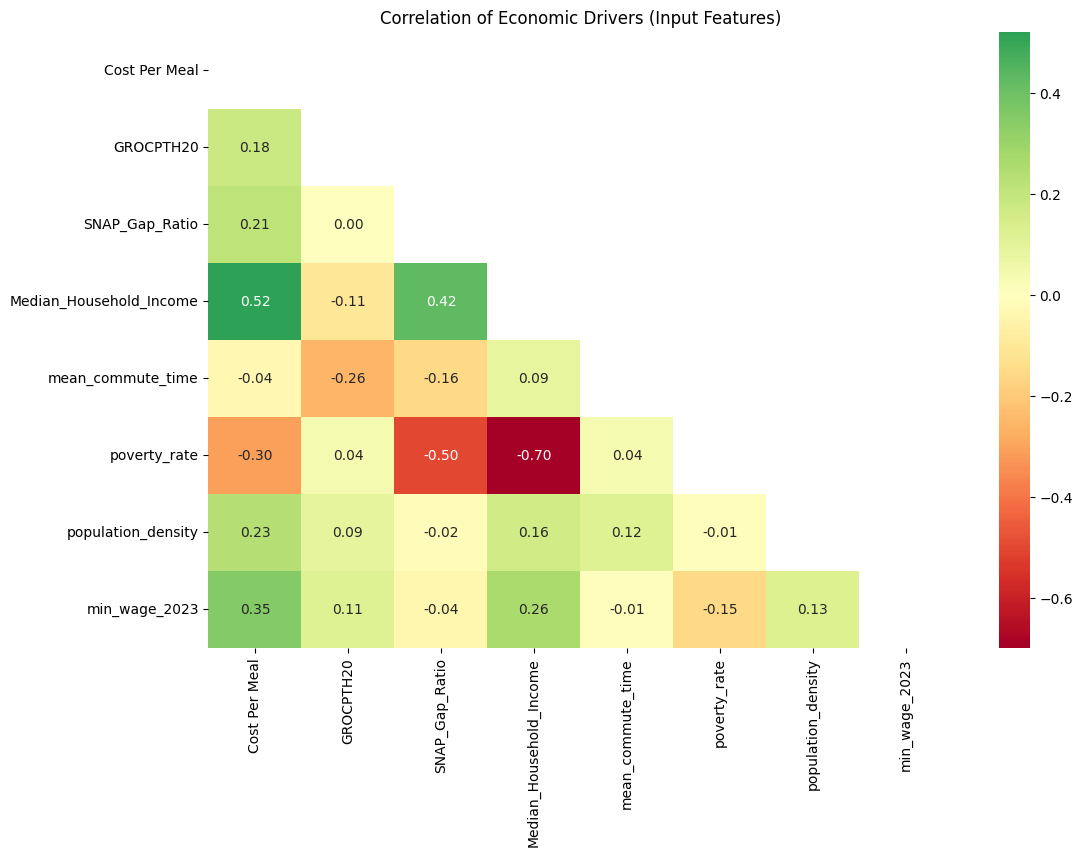

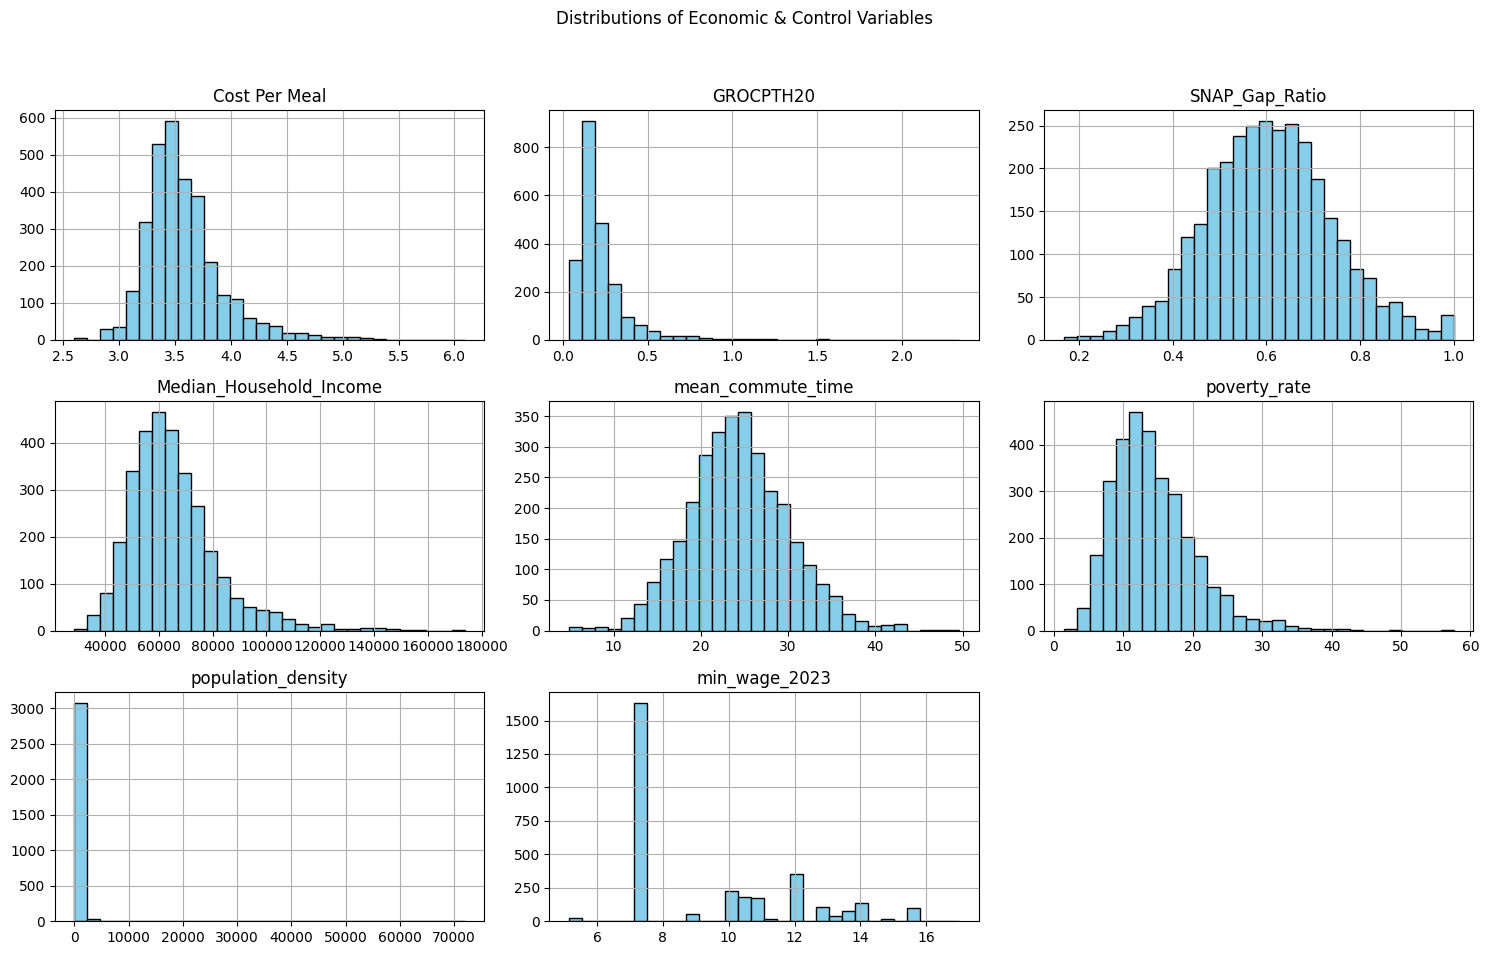

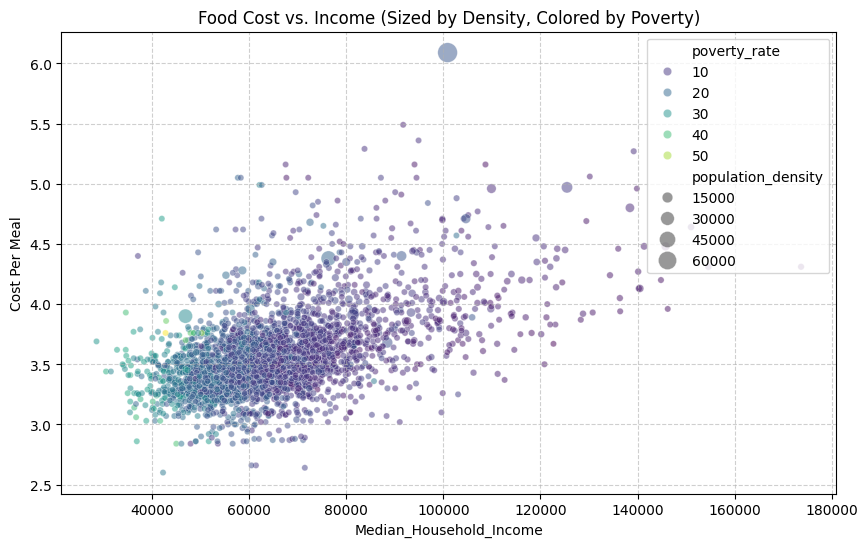

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

file_path = 'master_merged_8_files.csv'

if not os.path.exists(file_path):
    print(f"Error: {file_path} not found. Please check the file name in your directory.")
else:
    df = pd.read_csv(file_path)
    
    # 2. DATA CLEANING FOR EDA
    # Convert Median Income to numeric (removing commas/signs)
    if 'Median_Household_Income' in df.columns:
        df['Median_Household_Income'] = pd.to_numeric(
            df['Median_Household_Income'].astype(str).str.replace(r'[$,]', '', regex=True), 
            errors='coerce'
        )

    # Calculate SNAP Gap Ratio (Gap relative to the population in poverty)
    if 'No_SNAP_Below_Poverty_Gap' in df.columns and 'Total_Below_Poverty' in df.columns:
        df['SNAP_Gap_Ratio'] = df['No_SNAP_Below_Poverty_Gap'] / df['Total_Below_Poverty']

    # 3. DEFINE KEY FEATURES FOR THE "WHAT-IF" MODEL
    key_features = [
        'Cost Per Meal',                # Food Price Index
        'GROCPTH20',                   # Grocery Store Density
        'SNAP_Gap_Ratio',              # Eligibility Gaps (Normalized)
        'Median_Household_Income',      # Median Income
        'mean_commute_time',           # Transportation Proxy
        'poverty_rate',                # Census Poverty Rate
        'population_density',          # Urbanization Control
        'min_wage_2023'                # State Minimum Wage
    ]

    # --- INITIAL INSPECTION ---
    print(f"Dataset contains {df.shape[0]} counties and {df.shape[1]} columns.")
    print("\n--- Missing Values in Key Columns ---")
    print(df[key_features].isnull().sum())

    # --- SUMMARY STATISTICS ---
    display(df[key_features].describe().T)

    # --- VISUALIZATION 1: CORRELATION HEATMAP ---
    # This shows how your "Affordability" and "Control" variables interact
    plt.figure(figsize=(12, 8))
    corr = df[key_features].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
    plt.title('Correlation of Economic Drivers (Input Features)')
    plt.show()

    # --- VISUALIZATION 2: DISTRIBUTIONS ---
    # Important to see if we need Log Scaling (common for Population Density)
    df[key_features].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
    plt.suptitle('Distributions of Economic & Control Variables')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- VISUALIZATION 3: THE "AFFORDABILITY" RELATIONSHIP ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Median_Household_Income', y='Cost Per Meal', 
                    hue='poverty_rate', size='population_density', 
                    sizes=(20, 200), alpha=0.5, palette='viridis')
    plt.title('Food Cost vs. Income (Sized by Density, Colored by Poverty)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()